Milestone 4: Incident Type Analysis
Project: Analysis of U.S. Natural Disaster Declarations

Objective
The objective of this milestone is to analyze different disaster incident types and understand their distribution across various states. This includes identifying the most frequent disaster categories and examining regional variations.

This analysis also integrates insights from previous milestones such as temporal trends and geographic patterns to provide a complete understanding of disaster occurrences.

Key Questions
- Which disaster types occur most frequently?
- How are disaster types distributed across different states?
- What regional patterns can be observed in disaster occurrences?
- What overall insights can be derived from the analysis?

Dataset Description
The dataset used for this analysis is a cleaned version of U.S. natural disaster declarations data. It includes key attributes such as incident type, state, year, and month.

Tools Used
- Pandas for data manipulation and aggregation  
- Matplotlib for visualization  
- Seaborn for advanced plots and heatmaps  



In [ ]:
#Importing required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("usnd_cleaned.csv")

# Check data
df.head()

,state,incidentType,date,year,month
0,GA,Tornado,1953-05-02,1953,5
1,TX,Tornado,1953-05-15,1953,5
2,LA,Flood,1953-05-29,1953,5
3,MI,Tornado,1953-06-02,1953,6
4,MT,Flood,1953-06-06,1953,6


In [ ]:
#Basic info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46185 entries, 0 to 46184
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   state         46185 non-null  object
 1   incidentType  46185 non-null  object
 2   date          46185 non-null  object
 3   year          46185 non-null  int64 
 4   month         46185 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.8+ MB


,year,month
count,46185.000000,46185.000000
mean,1998.361264,6.019898
std,13.249703,3.167001
min,1953.000000,1.000000
25%,1993.000000,3.000000
50%,2003.000000,6.000000
75%,2008.000000,9.000000
max,2017.000000,12.000000


In [7]:
# Incident Type Distribution
incident_summary = (
    df.groupby("incidentType")
    .size()
    .reset_index(name="Total_Count")
    .sort_values(by="Total_Count", ascending=False)
)

incident_summary

,incidentType,Total_Count
12,Storm,16250
5,Flood,9317
7,Hurricane,8764
11,Snow,3565
4,Fire,2647
8,Ice,1970
14,Tornado,1412
2,Drought,1292
19,Winter,301
10,Other,297


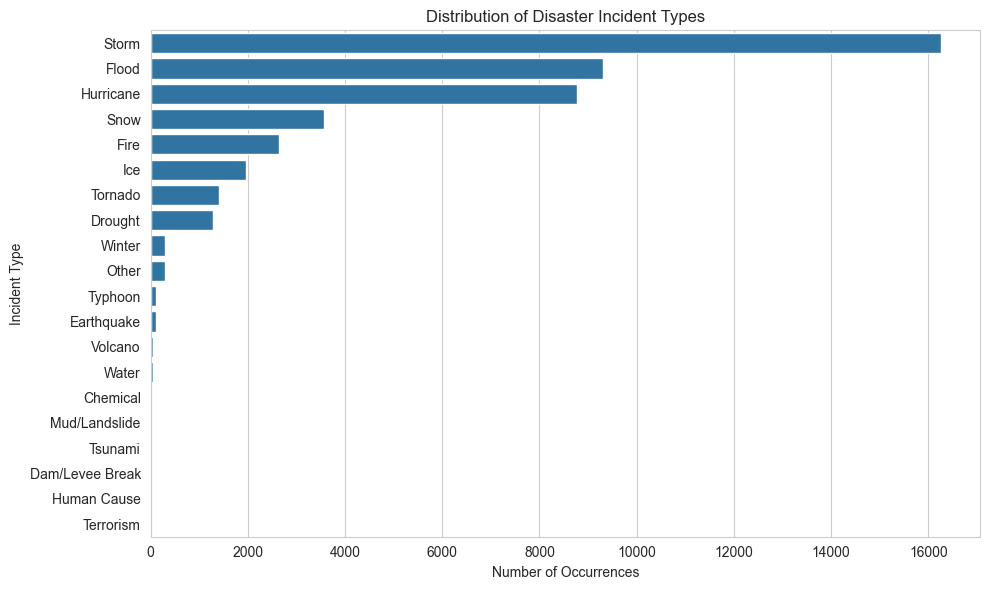

In [ ]:
#bar chart
plt.figure(figsize=(10,6))
sns.barplot(data=incident_summary, y="incidentType", x="Total_Count")

plt.title("Distribution of Disaster Incident Types")
plt.xlabel("Number of Occurrences")
plt.ylabel("Incident Type")

plt.tight_layout()
plt.show()

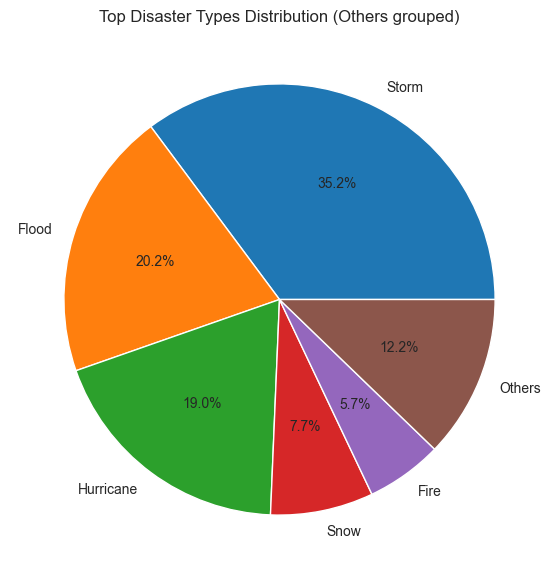

In [14]:
#pie Chart
# Show only top 5 + others (clean visualization)

top5 = incident_summary.head(5)
others = pd.DataFrame({
    "incidentType": ["Others"],
    "Total_Count": [incident_summary["Total_Count"][5:].sum()]
})

plot_data = pd.concat([top5, others])

plt.figure(figsize=(7,7))
plt.pie(
    plot_data["Total_Count"],
    labels=plot_data["incidentType"],
    autopct="%1.1f%%"
)

plt.title("Top Disaster Types Distribution (Others grouped)")
plt.show()

In [10]:
#State Vs Incident Analysis
state_incident = (
    df.groupby(["state", "incidentType"])
    .size()
    .reset_index(name="Count")
)

state_incident.head()

,state,incidentType,Count
0,AK,Earthquake,7
1,AK,Fire,16
2,AK,Flood,46
3,AK,Other,4
4,AK,Snow,4


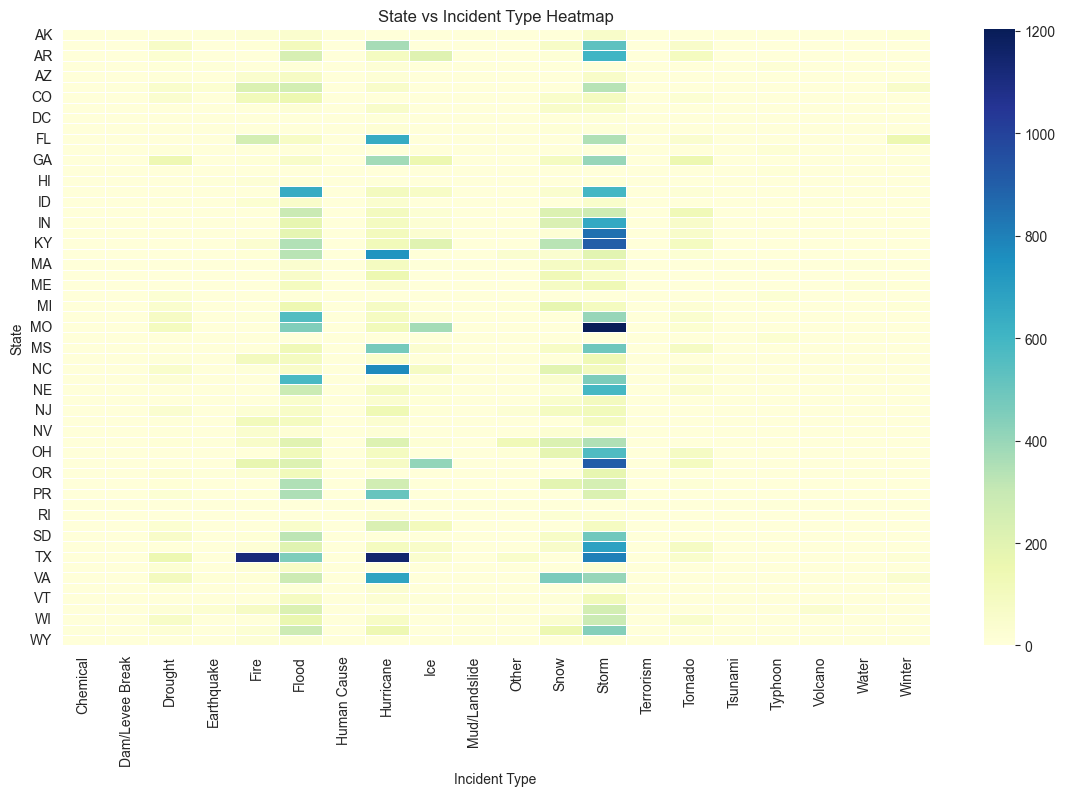

In [11]:
#heat Map 
heatmap_data = state_incident.pivot_table(
    index="state",
    columns="incidentType",
    values="Count",
    fill_value=0
)

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5)

plt.title("State vs Incident Type Heatmap")
plt.xlabel("Incident Type")
plt.ylabel("State")

plt.show()

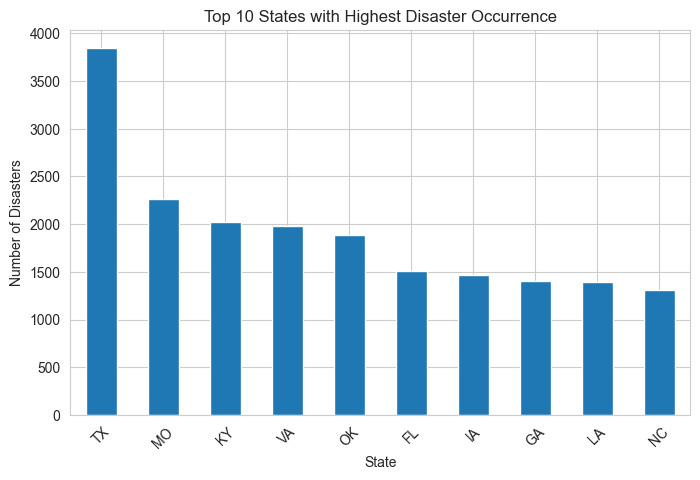

In [12]:
#Top states 
top_states = df["state"].value_counts().head(10)

plt.figure(figsize=(8,5))
top_states.plot(kind="bar")

plt.title("Top 10 States with Highest Disaster Occurrence")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.xticks(rotation=45)
plt.show()

In [13]:
#Assistance Analysis 
if 'ihProgramDeclared' in df.columns and 'paProgramDeclared' in df.columns:
    
    assistance = (
        df.groupby("incidentType")[["ihProgramDeclared", "paProgramDeclared"]]
        .sum()
        .reset_index()
    )

    assistance.set_index("incidentType").plot(kind="bar", figsize=(10,6))

    plt.title("Assistance Programs by Incident Type")
    plt.xlabel("Incident Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

else:
    print("Assistance columns not available in dataset")

Assistance columns not available in dataset


Final Insights:

- Disaster events such as floods and storms are the most frequently occurring incident types.
- Certain states consistently experience higher disaster occurrences, indicating regional risk patterns.
- The distribution of disasters varies significantly across states, showing strong geographic influence.
- Analysis from previous milestones indicates that disaster occurrences show temporal trends and regional concentration.
- Due to dataset limitations, assistance program analysis could not be fully explored.